In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
import time

# 5章演習問題

## (1) 離散時間システムについて

### (a)線形性と時不変性が成り立っているかどうか

係数が定数であるものは時不変システム、係数が時間に依存するものは時変システム

i. $y(n)=x^{2}(n)$
- 線形性：不成立
- 時不変性：成立

ii. $y(n)=\alpha x(n+1) + \beta x(n)$
- 線形性：成立
- 時不変性：成立

iii. $y(n)=n x(n)$
- 線形性：成立
- 時不変性：不成立

iv. $y(n) = \alpha y(n-1) + \beta x(n)$
- 線形性：成立
- 時不変性：成立

式変形すると$y(n)=\beta\Sigma_{k=0}^{n-1}\alpha^{n-k-1}x(n)$と書けるので，
\begin{align}
\beta\Sigma_{k=0}^{n-1}\alpha^{n-k-1}(a_{1}x_{1}(k)+a_{2}x_{2}(k))
=a_{1}(\beta\Sigma_{k=0}^{n-1}\alpha^{n-k-1}x_{1}(k))+a_{2}(\beta\Sigma_{k=0}^{n-1}\alpha^{n-k-1}x_{2}(k))\\
\end{align}
から線形性が成り立つ．



v. $y(n) = {\rm median}[x(n-1), x(n), x(n+1)]$
- 線形性：不成立
- 時不変性：不成立

### (b) インパルス応答

i. $y(n)=x^{2}(n)$

\begin{align}
y(-1) &= \delta(-1)^2 = 0\\
y(0) &= \delta(0)^2 = 1\\
y(1) &= \delta(1)^2 = 0\\
\dots \\
y(n) &= \left\{
\begin{aligned}
&1,\ \ \ \ n=0\\
&0,\ \ \ \ n\neq 0 \\
\end{aligned}
\right.
\end{align}

ii. $y(n)=\alpha x(n+1) + \beta x(n)$

\begin{align}
y(-2) &= \alpha\delta(-1) + \beta\delta(-2) = 0\\
y(-1) &= \alpha\delta(0) + \beta\delta(-1) = \alpha\\
y(0) &= \alpha\delta(1) + \beta\delta(0) = \beta\\
y(1) &= \alpha\delta(2) + \beta\delta(1) = 0\\
\dots \\
y(n) &= \left\{
\begin{aligned}
&\alpha,\ \ \ \ n=-1\\
&\beta,\ \ \ \ n=0\\
&0,\ \ \ \ otherwise \\
\end{aligned}
\right.
\end{align}

iii. $y(n)=n x(n)$

\begin{align}
y(-1) &= -1\cdot \delta(-1) = 0\\
y(0) &= 0\cdot \delta(0) = 0\\
y(1) &= 1\cdot \delta(1) = 0\\
\dots \\
y(n) &= 0
\end{align}


iv. $y(n) = \alpha y(n-1) + \beta x(n)$

\begin{align}
y(-1) &= \alpha y(-2) + \beta \delta(-1) = 0 ?\\
y(0) &= \alpha y(-1) + \beta \delta(0) = \beta \\
y(1) &= \alpha y(0) + \beta \delta(1) = \alpha \beta \\
y(2) &= \alpha y(1) + \beta \delta(2) = \alpha^2 \beta\\
\dots \\
y(n) &= \alpha^{n}\beta
\end{align}

v. $y(n) = {\rm median}[x(n-1), x(n), x(n+1)]$

ここでのmedianは振幅でソートした時の中央の値

\begin{align}
y(0) &= {\rm median}[\delta(-1), \delta(0), \delta(1)] = 0 \\
y(1) &= {\rm median}[\delta(0), \delta(1), \delta(2)] = 0 \\
y(2) &= {\rm median}[\delta(1), \delta(2), \delta(3)] = 0\\
\dots \\
y(n) &= 0
\end{align}

### (c) 線形・時不変システムのたたみこみによる表現

たたみこみ:  $\Sigma_{k=-\infty}^{\infty}x(k)h(n-k)=\Sigma_{k=-\infty}^{\infty}x(n-k)h(k)$

$h(n)$は単位インパルス応答で，(b)ですでに求めているものを用いる．



ii. $y(n)=\alpha x(n+1) + \beta x(n)$

\begin{align}
y(n) &= \Sigma_{k=-\infty}^{\infty}x(k)h(n-k) = \alpha x(n+1) + \beta x(n)
\end{align}

iv. $y(n) = \alpha y(n-1) + \beta x(n)$

\begin{align}
y(n) &= \Sigma_{k=-\infty}^{\infty}x(k)h(n-k) = \Sigma_{k=-\infty}^{\infty}\alpha^{n-k}\beta x(k)
\end{align}

## (2) たたみこみ

### (a)

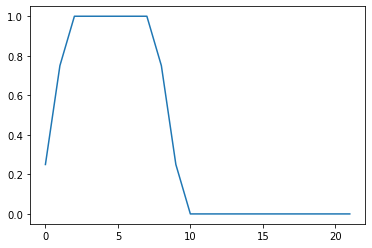

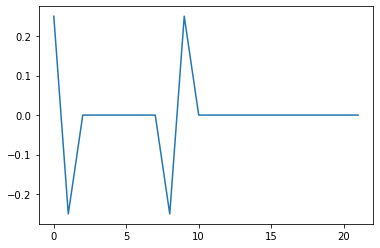

In [2]:
N = 20

x = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
x = np.array(x + [0.0 for i in range(N-len(x))])

h1 = np.array([1.0, 2.0, 1.0]) / 4.0

xh1 = np.convolve(x, h1)
plt.plot(xh1)
plt.show()

h2 = np.array([1.0, -2.0, 1.0]) / 4.0
xh2 = np.convolve(x, h2)
plt.plot(xh2)
plt.show()

重み付き平均の働きをしている．

### (b)

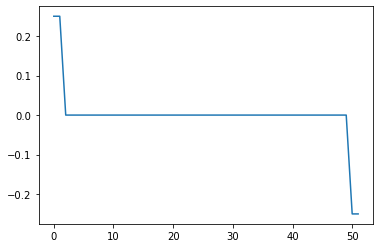

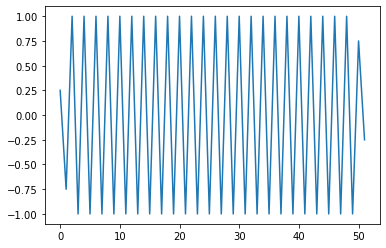

In [3]:
N = 50
x = np.array([(-1.0)**i for i in range(N)])

h1 = np.array([1.0, 2.0, 1.0]) / 4.0

xh1 = np.convolve(x, h1)
plt.plot(xh1)
plt.show()

h2 = np.array([1.0, -2.0, 1.0]) / 4.0
xh2 = np.convolve(x, h2)
plt.plot(xh2)
plt.show()

## (3) たたみこみの式

\begin{align}
y(n) &= \Sigma_{k=-\infty}^{\infty}x(k)h(n-k)\\
\end{align}
$n-k=\ell$と置き，$k=n-\ell$から

\begin{align}
y(n) &= \Sigma_{n-\ell=-\infty}^{\infty}x(n-\ell)h(\ell)\\
&= \Sigma_{n=-\infty}^{\infty}x(n-\ell)h(\ell)\\
\end{align}

改めて$\ell$を$k$と書き直して
\begin{align}
y(n) &= \Sigma_{n=-\infty}^{\infty}x(n-k)h(k)\\
\end{align}




## (4) ディジタルフィルタの従属接続

### (a)

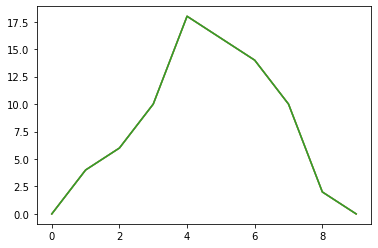

In [4]:
h1 = np.array([1.0, 1.0, 1.0, 1.0])
h2 = np.array([0.0, 2.0, 2.0, 0.0])
x = [2.0, -1.0, 3.0, 1.0]

#Npad = 2 * len(x) - 1 - len(x)
#x = x + [0 for i in range(Npad)]

wa = np.convolve(x, h1)
ya = np.convolve(wa, h2)

wb = np.convolve(x, h2)
yb = np.convolve(wb, h1)

h12 = np.convolve(h1, h2)
yc = np.convolve(x, h12)

plt.plot(ya)
plt.plot(yb)
plt.plot(yc)
plt.show()

### (b)

図5.5 (a)から

\begin{align}
y(n) &= \Sigma_{k=-\infty}^{\infty}h_2(n-k)w_a(k)　\tag{1}\\
w_a(n) &= \Sigma_{\ell=-\infty}^{\infty}h_1(\ell)x(n-\ell) \tag{2}\\
\end{align}

式(2)，(1)を各々離散時間フーリエ変換すると，

\begin{align}
Y(e^{j\omega}) &= H_2(e^{j\omega})W_a(e^{j\omega})　\tag{3}\\
W_a(e^{j\omega}) &= H_1(e^{j\omega})X(e^{j\omega}). \tag{4}
\end{align}

式(4)を3に代入して
\begin{align}
Y(e^{j\omega}) &= H_2(e^{j\omega})(H_1(e^{j\omega})X(e^{j\omega}))　\tag{5}\\
&= H_1(e^{j\omega})(H_2(e^{j\omega})X(e^{j\omega})) \tag{6}\\
&= (H_1(e^{j\omega})H_2(e^{j\omega}))X(e^{j\omega}) \tag{7}\\
\end{align}

式(5)~(7)を離散時間フーリエ逆変換することで図5.5 (b)，(c)の表現が得られる．

## (5) 安定性

### (a) 証明

安定の定義は，有界な入力に対して出力が有界になることであるから，入力を$x(n)$としたときに，$|x(n)| < c$ならば$y(n)$が有界となることを示す．
ただし，$c$は定数．

\begin{align}
|y(n)| &= \left| \Sigma_{k=-\infty}^{\infty}h(k)x(n-k) \right|\\
&\le \Sigma_{k=-\infty}^{\infty}|h(k)||x(n-k)|\\
&\le c\Sigma_{k=-\infty}^{\infty}|h(k)|
\end{align}

上の式から，$\Sigma_{k=-\infty}^{\infty}|h(k)|<\infty$であれば$y(n)$は有界で，$y(n)$が有界な場合，$\Sigma_{k=-\infty}^{\infty}|h(k)|<\infty$が成り立つ．

### (b) 安定性

i. 安定

ii. 不安定

iii. $|\alpha| < 1$で安定

iv. $|\alpha| < 1$で安定

v. 不安定

## (6) 因果性

### (a) 証明
因果性：全ての$n\le n_0$において等しい任意の二つの入力$x_1(n)$,$x_2(n)$に対するそれぞれの出力$y_1(n)$,$y_2(n)$が等しい

\begin{align}
y_1(n) &= \Sigma_{k=-\infty}^{\infty}h(n-k)x_1(k)
= \Sigma_{k=-\infty}^{n_0}h(n-k)x_1(k) + \Sigma_{k=n_0+1}^{\infty}h(n-k)x_1(k)\\
y_2(n) &= \Sigma_{k=-\infty}^{\infty}h(n-k)x_2(k)
= \Sigma_{k=-\infty}^{n_0}h(n-k)x_2(k) + \Sigma_{k=n_0+1}^{\infty}h(n-k)x_2(k)\\
\end{align}

右辺の第1項は等しいと言えるので，第2項が0であれば因果性を満たす．任意の入力に対して第２項が0になるには，$k=n_0+1, n_0+2,\cdots$で
$h(n-k)=0$となれば良い．すなわち，$h(n-n_0-1)=h(n-n_0-2)=\cdots = 0$．これが全ての$n\le n_0$に対して成り立つのは$h(n)=0, n\lt 0$のとき．

### (b) 問題(1)のシステムの因果性

問題(1)で求めたインパルス応答が$n<0$で0となるかどうかで判定する．

i. 因果的

ii. 非因果的

iii. 因果的

iv. 因果的？

v. 因果的

## (7) 2次再帰型フィルタ$y(n)=0.5y(n-1)-0.25y(n-2)+x(n)+2x(n-1)+x(n-2)$について

### (a) ブロック図

ppt

### (b) 単位インパルス応答と単位ステップ応答の図示

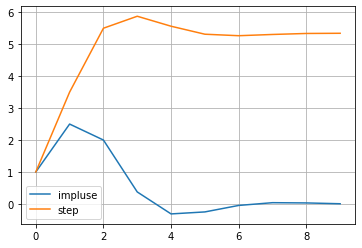

In [5]:
def unit_impluse(n):
    if n == 0:
        delta = 1
    else:
        delta = 0
    return delta

def unit_step(n):
    if n >= 0:
        u = 1
    else:
        u = 0
    return u

class iir2(object):
    def __init__(self, a, b):
        self.a = a
        self.b = b
        self.buf = np.zeros(2)
        
    def partial_fit(self, x):
        feedback = self.a[0] * self.buf[0] + self.a[1] * self.buf[1]
        feedforward = self.b[1] * self.buf[0] + self.b[2] * self.buf[1]
        self.buf[1] = self.buf[0]
        self.buf[0] = x + feedback
        return self.b[0] * self.buf[0] + feedforward
    
N = 10
iir = iir2(a=np.array([0.5, -0.25]), b=np.array([1.0, 2.0, 1.0]))
response_i = np.zeros(N)
for n in range(N):
    response_i[n] = iir.partial_fit(unit_impluse(n))

iir = iir2(a=np.array([0.5, -0.25]), b=np.array([1.0, 2.0, 1.0]))
response_u = np.zeros(N)
for n in range(N):
    response_u[n] = iir.partial_fit(unit_step(n))
    
plt.plot(range(N), response_i, label="impluse")
plt.plot(range(N), response_u, label="step")
plt.legend()
plt.grid()
plt.show()

### (c) 周波数応答，振幅特性，位相特性

周波数応答

\begin{align}
H(e^{j\omega})=\frac{1+2e^{-j\omega}+e^{-j\omega 2}}{1-0.5e^{-j\omega}+0.25e^{-j\omega 2}}
\end{align}

振幅特性

$H(e^{j\omega})H^{*}(e^{j\omega})$を計算して平方根をとる．

\begin{align}
(分母) &= \left( 1 - \frac{1}{2}e^{-j\omega}+\frac{1}{4}e^{-j2\omega} \right) \left( 1 - \frac{1}{2}e^{j\omega} + \frac{1}{4}e^{j2\omega} \right)\\
&= 1 + \frac{1}{4} + \frac{1}{16} - \frac{5}{4}\frac{e^{j\omega}+e^{-j\omega}}{2} + \frac{1}{2}\frac{e^{j2\omega}+e^{-j2\omega}}{2}\\
&= \frac{21}{16}-\frac{5}{4}\cos{\omega}+\frac{1}{2}\cos{2\omega}\\
(分子) &= \left( 1+2e^{-j\omega}+e^{-j2\omega} \right)\left( 1+2e^{j\omega}+e^{j2\omega} \right)\\
&= 6 + 8\frac{e^{j\omega}+e^{-j\omega}}{2}+2\frac{e^{j2\omega}+e^{-j2\omega}}{2}\\
&= 6 + 8\cos{\omega} + 2\cos{2\omega}\\
|H(e^{j\omega})| &= \sqrt{\frac{6 + 8\cos{\omega} + 2\cos{2\omega}}{\frac{21}{16}-\frac{5}{4}\cos{\omega}+\frac{1}{2}\cos{2\omega}}}\\
&= 4\sqrt{\frac{6 + 8\cos{\omega} + 2\cos{2\omega}}{21-20\cos{\omega}+8\cos{2\omega}}}\\
\end{align}

位相特性

有理化して実部，虚部を求め，$\tan^{-1}{\frac{虚部}{実部}}$を計算する．有理化した後の分母は上で求めたものと同じになるが，虚部と実部の比をとると消えるので無視して良い．

\begin{align}
(分子) &= \left( 1+2e^{-j\omega}+e^{-j2\omega} \right) \left( 1- \frac{1}{2}e^{j\omega}+\frac{1}{4}e^{j2\omega} \right)\\
&= \frac{1}{4} + \frac{7}{4}\cos{\omega} + \cos{2\omega} + j \left( -\frac{3}{2}\sin{\omega} - \frac{3}{4}\sin{2\omega} \right)
\end{align}

\begin{align}
\theta(\omega) &= \tan^{-1}\left( \frac{-\frac{3}{2}\sin{\omega} - \frac{3}{4}\sin{2\omega}}{\frac{1}{4} + \frac{7}{4}\cos{\omega} + \cos{2\omega}} \right)\\
&= \tan^{-1}\left( \frac{-6\sin{\omega} - 3\sin{2\omega}}{1 + 7\cos{\omega} + 4\cos{2\omega}} \right)
\end{align}


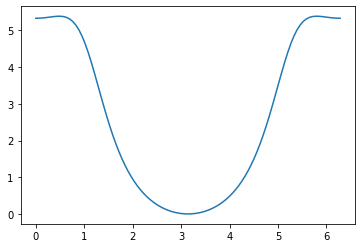

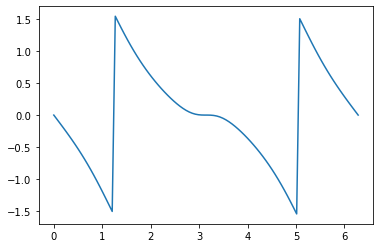

In [6]:
omega = np.linspace(0, 2.0*np.pi, 100)

a = 6.0 + 8.0 * np.cos(omega) + 2.0 * np.cos(2.0 * omega)
b = 21.0 - 20.0 * np.cos(omega) + 8.0 * np.cos(2.0 * omega)
H = 4.0 * np.sqrt(a / b)

c = -6.0 * np.sin(omega) - 3.0 * np.sin(2.0 * omega)
d = 1.0 + 7.0 * np.cos(omega) + 4.0 * np.cos(2.0 * omega)
theta = np.arctan(c / d)

plt.plot(omega, H)
plt.show()
plt.plot(omega, theta)
plt.show()

### (d) 各入力信号に対する定常状態における出力の振幅

i. $x(n) = [\cdots , 1, 1, \underline{1}, 1, 1, \cdots]$

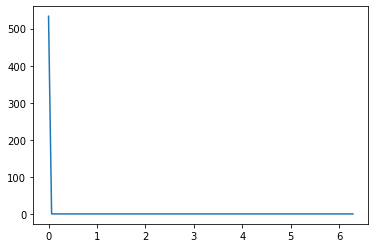

In [7]:
x = [1.0 for i in range(len(H))]
X = np.fft.fft(x)
HX = H * np.abs(X)

plt.plot(omega, HX)
plt.show()

ii. $x(n) = [\cdots , 1, j, -1, -j, \underline{1}, j, -1, -j, 1, \cdots]$

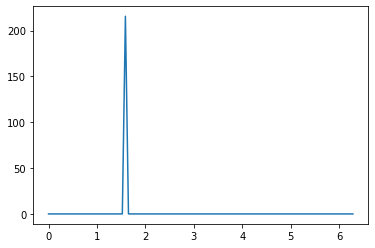

In [8]:
x = np.zeros(len(H), dtype="complex")
for i in range(len(H)):
    if i % 4 == 0:
        x[i] = 1.0 + 0.0j
    elif i % 4 == 1:
        x[i] = 0.0 + 1.0j
    elif i % 4 == 2:
        x[i] = -1.0 + 0.0j
    else:
        x[i] = -0.0 + -1.0j

X = np.fft.fft(x)
HX = H * np.abs(X)

plt.plot(omega, HX)
plt.show()

iii. $x(n) = [\cdots, 1, -1, \underline{1}, -1, \cdots]$

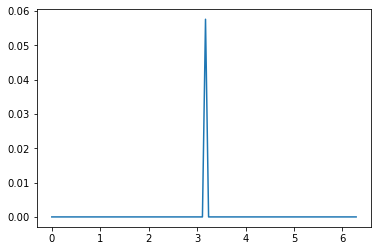

In [9]:
x = [(-1)**i for i in range(len(H))]

X = np.fft.fft(x)
HX = H * np.abs(X)

plt.plot(omega, HX)
plt.show()

## (8) 4次非再帰型フィルタ$y(n)=x(n)+4x(n-1)+6x(n-2)+4x(n-3)+x(n-4)$について

### (a) ブロック図

ppt

### (b) 単位インパルス応答と単位ステップ応答の図示

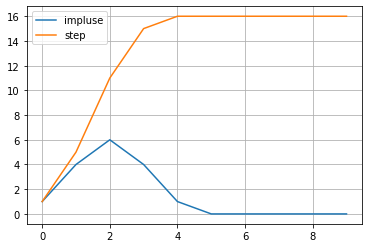

In [11]:
class fir4(object):
    def __init__(self, b):
        self.b = b
        self.buf = np.zeros(5)
        
    def partial_fit(self, x):
        for i in range(4):
            self.buf[4-i] = self.buf[4-i-1]
        self.buf[0] = x
        return np.dot(self.b, self.buf)
    
N = 10
fir = fir4(b=np.array([1.0, 4.0, 6.0, 4.0, 1.0]))
response_i = np.zeros(N)
for n in range(N):
    response_i[n] = fir.partial_fit(unit_impluse(n))

fir = fir4(b=np.array([1.0, 4.0, 6.0, 4.0, 1.0]))
response_u = np.zeros(N)
for n in range(N):
    response_u[n] = fir.partial_fit(unit_step(n))
    
plt.plot(range(N), response_i, label="impluse")
plt.plot(range(N), response_u, label="step")
plt.legend()
plt.grid()
plt.show()

### (c) 周波数応答，振幅特性，位相特性

周波数応答

\begin{align}
H(e^{j\omega})=1+4e^{-j\omega}+6e^{-j2\omega}+4e^{-j3\omega}+e^{-j4\omega}
\end{align}

振幅特性

$H(e^{j\omega})H^{*}(e^{j\omega})$を計算して平方根をとる．

\begin{align}
|H(e^{j\omega})| &= \sqrt{70 + 112\cos{\omega} +　56\cos{2\omega} + 16\cos{3\omega} + 2\cos{4\omega}}\\
\end{align}

位相特性

\begin{align}
H(e^{j\omega}) &= \left( 1 + 4\cos{\omega} + 6\cos{2\omega} + 4\cos{3\omega} + \cos{4\omega} \right)
-j \left( 4\sin{\omega} + 6\sin{2\omega} + 4\sin{3\omega} + \sin{4\omega} \right)\\
\end{align}

\begin{align}
\theta(\omega) &= \tan^{-1}\left( -\frac{4\sin{\omega} + 6\sin{2\omega} + 4\sin{3\omega} + \sin{4\omega}}{1 + 4\cos{\omega} + 6\cos{2\omega} + 4\cos{3\omega} + \cos{4\omega}} \right)\\
\end{align}


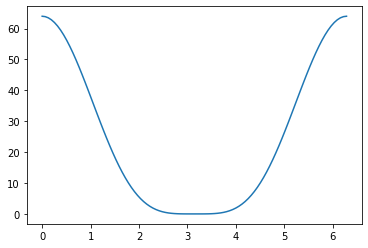

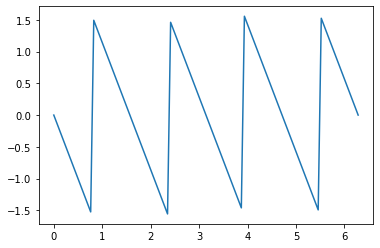

In [13]:
omega = np.linspace(0, 2.0*np.pi, 100)

H = 4.0 * np.sqrt(70.0 + 112.0 * np.cos(omega) + 56.0 * np.cos(2.0 * omega) + 16.0 * np.cos(3.0 * omega) + 2.0 * np.cos(4.0 * omega))

c = -4.0 * np.sin(omega) - 6.0 * np.sin(2.0 * omega) - 4.0 * np.sin(3.0 * omega) - np.sin(4.0 * omega)
d = 1.0 + 4.0 * np.cos(omega) + 6.0 * np.cos(2.0 * omega) + 4.0 * np.cos(3.0 * omega) + np.cos(4.0 * omega)
theta = np.arctan(c / d)

plt.plot(omega, H)
plt.show()
plt.plot(omega, theta)
plt.show()

### (d) 各入力信号に対する定常状態における出力の振幅

i. $x(n) = [\cdots , 1, 1, \underline{1}, 1, 1, \cdots]$

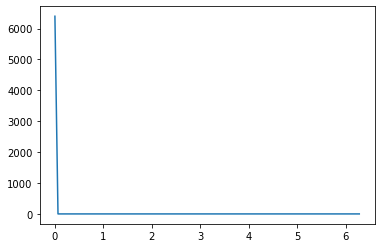

In [14]:
x = [1.0 for i in range(len(H))]
X = np.fft.fft(x)
HX = H * np.abs(X)

plt.plot(omega, HX)
plt.show()

ii. $x(n) = [\cdots , 1, j, -1, -j, \underline{1}, j, -1, -j, 1, \cdots]$

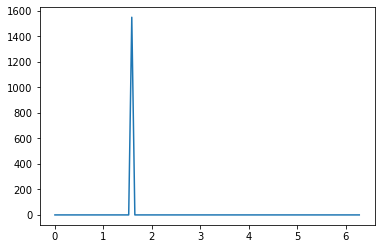

In [15]:
x = np.zeros(len(H), dtype="complex")
for i in range(len(H)):
    if i % 4 == 0:
        x[i] = 1.0 + 0.0j
    elif i % 4 == 1:
        x[i] = 0.0 + 1.0j
    elif i % 4 == 2:
        x[i] = -1.0 + 0.0j
    else:
        x[i] = -0.0 + -1.0j

X = np.fft.fft(x)
HX = H * np.abs(X)

plt.plot(omega, HX)
plt.show()

iii. $x(n) = [\cdots, 1, -1, \underline{1}, -1, \cdots]$

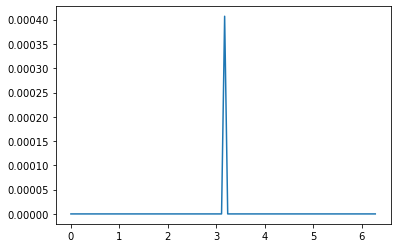

In [16]:
x = [(-1)**i for i in range(len(H))]

X = np.fft.fft(x)
HX = H * np.abs(X)

plt.plot(omega, HX)
plt.show()